# 🚗 Uber NCR Ride Bookings — Exploratory Data Analysis

This notebook performs a full EDA on the `ncr_ride_bookings.csv` dataset covering ride bookings in the National Capital Region (NCR).

**Dataset Columns:**
- **Date / Time** — When the ride was booked
- **Booking ID / Customer ID** — Unique identifiers
- **Booking Status** — Success, Cancelled, Incomplete, No Driver Found
- **Vehicle Type** — eBike, Go Sedan, etc.
- **Pickup / Drop Location** — Source and destination
- **Avg VTAT / Avg CTAT** — Vehicle / Customer Turnaround Time
- **Cancellation details** — By customer and driver with reasons
- **Booking Value, Ride Distance, Ratings, Payment Method**

## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. 📂 Load Dataset

In [2]:
df = pd.read_csv('ncr_ride_bookings.csv')

# Strip extra quotes that may appear in ID columns
for col in ['Booking ID', 'Customer ID']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip('"')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (150000, 21)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 3. 🔍 Basic Overview

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Statistical Summary ===')
df.describe(include='all')

=== Data Types ===
Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
dtype: object

=== Statistical Summa

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,...,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,...,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,CNR7908610,Completed,CID6468528,Auto,Khandsa,Ashram,NaN,NaN,...,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,...,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,...,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,...,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,...,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,...,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,...,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,...,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


## 4. 🧹 Data Cleaning

In [4]:
# --- Parse Date & Time ---
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
df['Hour']       = df['Datetime'].dt.hour
df['DayOfWeek']  = df['Datetime'].dt.day_name()
df['Month']      = df['Datetime'].dt.month_name()
df['MonthNum']   = df['Datetime'].dt.month

# --- Convert numerics ---
for col in ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Cleaned ✅')
df[['Datetime','Hour','DayOfWeek','Month']].head()

Cleaned ✅


,Datetime,Hour,DayOfWeek,Month
0,2024-03-23 12:29:38,12,Saturday,March
1,2024-11-29 18:01:39,18,Friday,November
2,2024-08-23 08:56:10,8,Friday,August
3,2024-10-21 17:17:25,17,Monday,October
4,2024-09-16 22:08:00,22,Monday,September


### 4.1 Missing Value Analysis

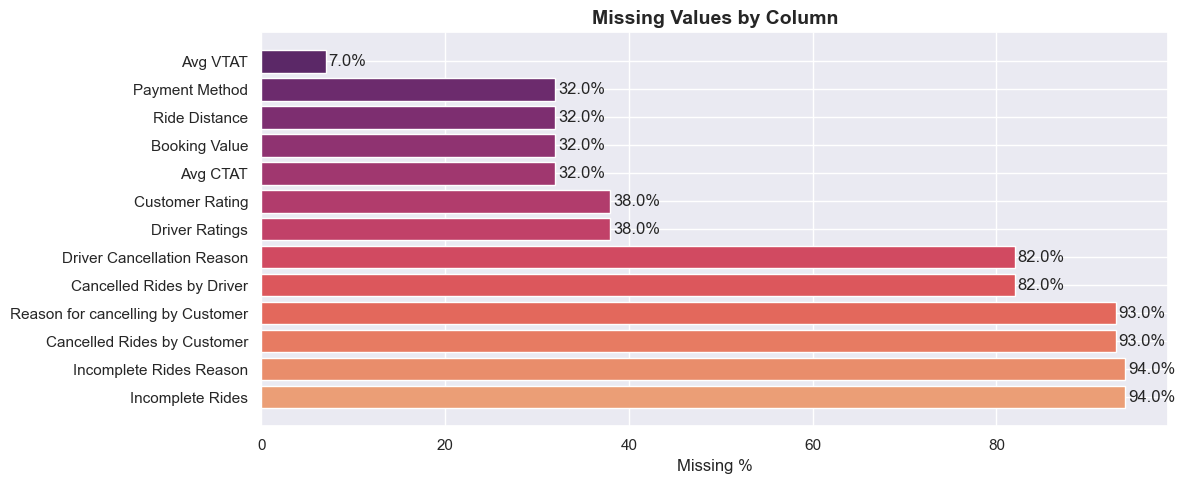

                                   Missing Count  Missing %
Incomplete Rides                          141000       94.0
Incomplete Rides Reason                   141000       94.0
Cancelled Rides by Customer               139500       93.0
Reason for cancelling by Customer         139500       93.0
Cancelled Rides by Driver                 123000       82.0
Driver Cancellation Reason                123000       82.0
Driver Ratings                             57000       38.0
Customer Rating                            57000       38.0
Avg CTAT                                   48000       32.0
Booking Value                              48000       32.0
Ride Distance                              48000       32.0
Payment Method                             48000       32.0
Avg VTAT                                   10500        7.0


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=sns.color_palette('flare', len(missing_df)))
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
plt.tight_layout()
plt.show()

print(missing_df)

## 5. 📊 Booking Status Distribution

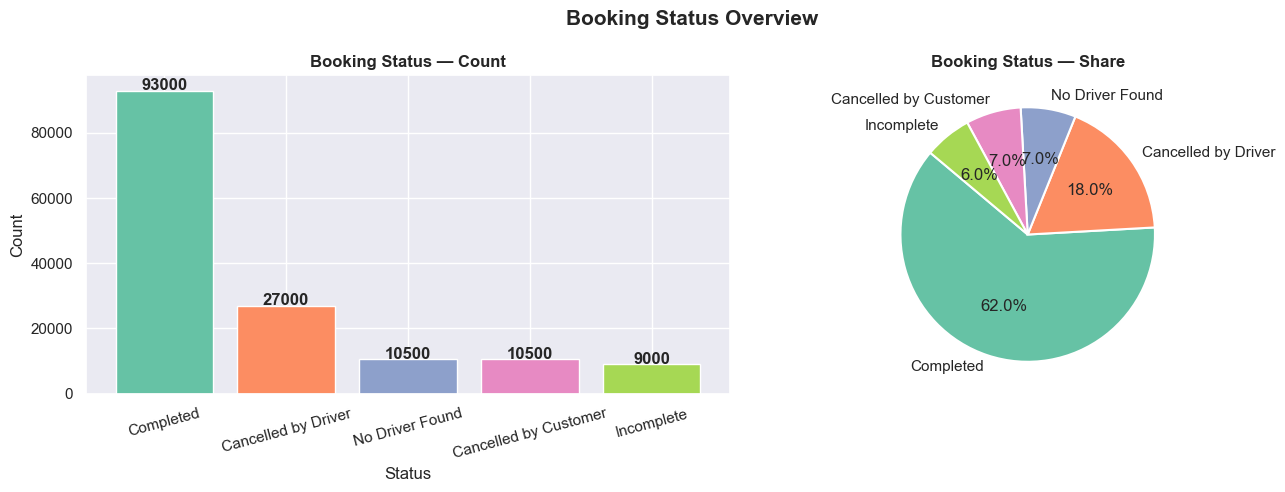

In [6]:
status_counts = df['Booking Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', len(status_counts))
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Booking Status — Count', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Booking Status — Share', fontweight='bold')

plt.suptitle('Booking Status Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 🚙 Vehicle Type Analysis

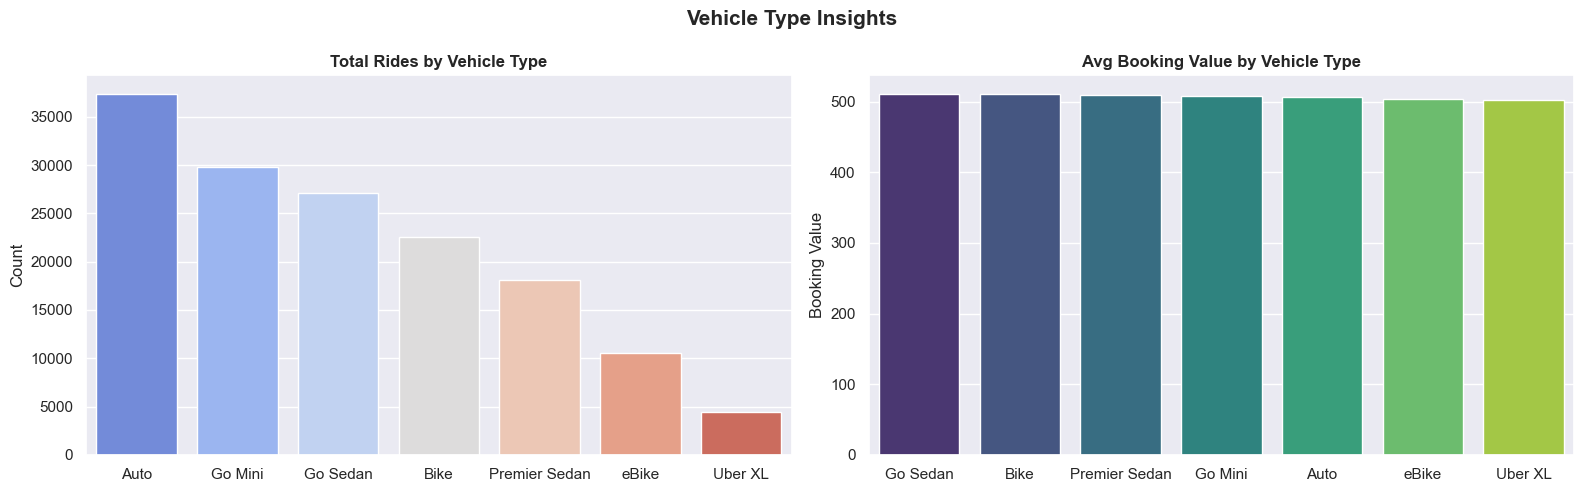

In [7]:
vt = df['Vehicle Type'].value_counts().reset_index()
vt.columns = ['Vehicle Type', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rides by vehicle type
sns.barplot(data=vt, x='Vehicle Type', y='Count', palette='coolwarm', ax=axes[0])
axes[0].set_title('Total Rides by Vehicle Type', fontweight='bold')
axes[0].set_xlabel('')

# Avg booking value by vehicle type
avg_val = df.groupby('Vehicle Type')['Booking Value'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_val, x='Vehicle Type', y='Booking Value', palette='viridis', ax=axes[1])
axes[1].set_title('Avg Booking Value by Vehicle Type', fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Vehicle Type Insights', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. ⏰ Time-Based Patterns

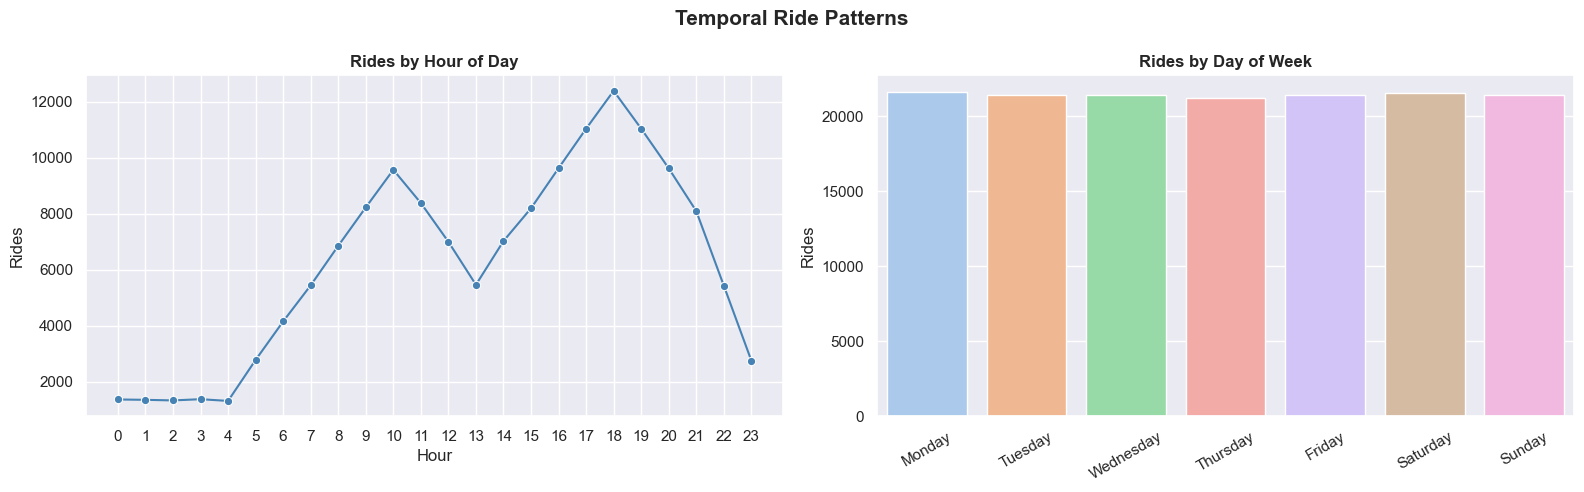

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rides by Hour
hourly = df.groupby('Hour').size().reset_index(name='Rides')
sns.lineplot(data=hourly, x='Hour', y='Rides', marker='o', color='steelblue', ax=axes[0])
axes[0].set_title('Rides by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_xticks(range(0, 24))

# Rides by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['DayOfWeek'].value_counts().reindex(day_order).reset_index()
daily.columns = ['Day', 'Rides']
sns.barplot(data=daily, x='Day', y='Rides', palette='pastel', ax=axes[1])
axes[1].set_title('Rides by Day of Week', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Temporal Ride Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

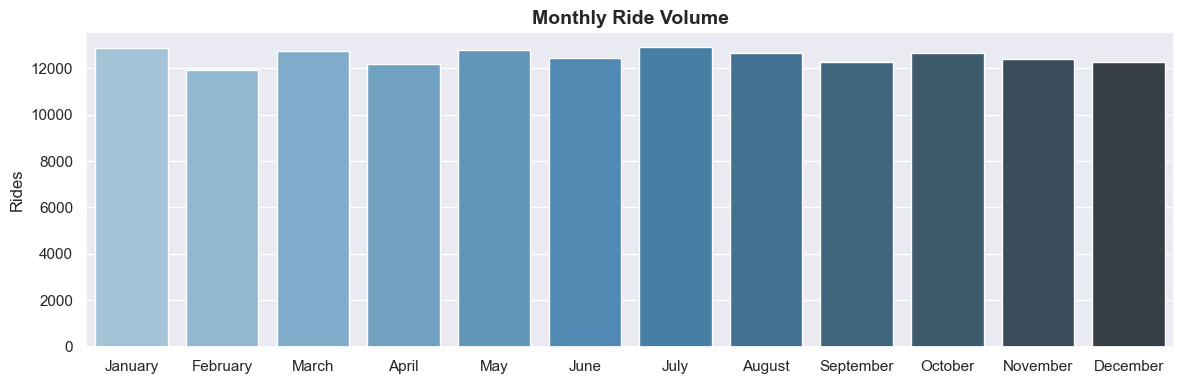

In [9]:
# Monthly ride trend
monthly = df.groupby(['MonthNum','Month']).size().reset_index(name='Rides').sort_values('MonthNum')

plt.figure(figsize=(12, 4))
sns.barplot(data=monthly, x='Month', y='Rides', palette='Blues_d')
plt.title('Monthly Ride Volume', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 8. ❌ Cancellation Analysis

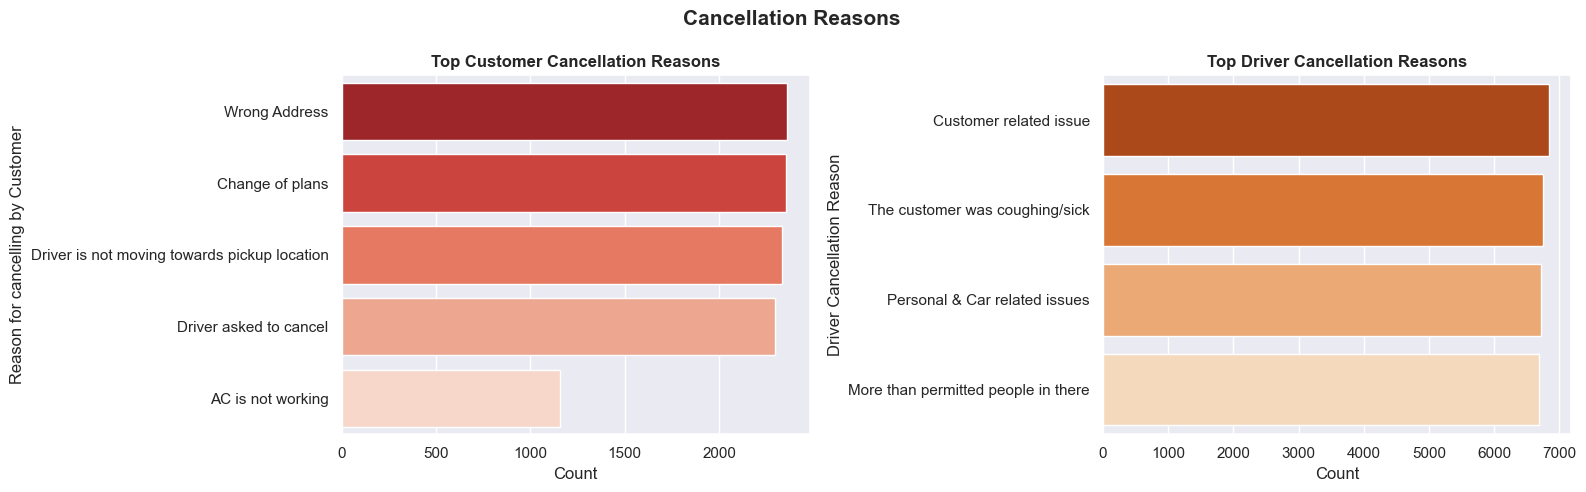

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Customer cancellation reasons
cust_cancel = df['Reason for cancelling by Customer'].dropna().value_counts().head(10)
sns.barplot(y=cust_cancel.index, x=cust_cancel.values, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top Customer Cancellation Reasons', fontweight='bold')
axes[0].set_xlabel('Count')

# Driver cancellation reasons
drv_cancel = df['Driver Cancellation Reason'].dropna().value_counts().head(10)
sns.barplot(y=drv_cancel.index, x=drv_cancel.values, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top Driver Cancellation Reasons', fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Cancellation Reasons', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

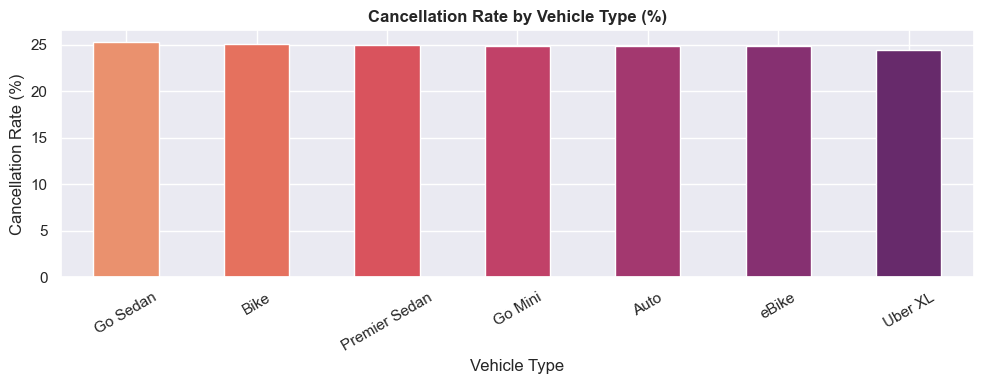

In [11]:
# Cancellation rate by vehicle type
df['Is_Cancelled'] = df['Booking Status'].str.contains('Cancelled', case=False, na=False).astype(int)
cancel_rate = df.groupby('Vehicle Type')['Is_Cancelled'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 4))
cancel_rate.plot(kind='bar', color=sns.color_palette('flare', len(cancel_rate)))
plt.title('Cancellation Rate by Vehicle Type (%)', fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. 📍 Location Analysis

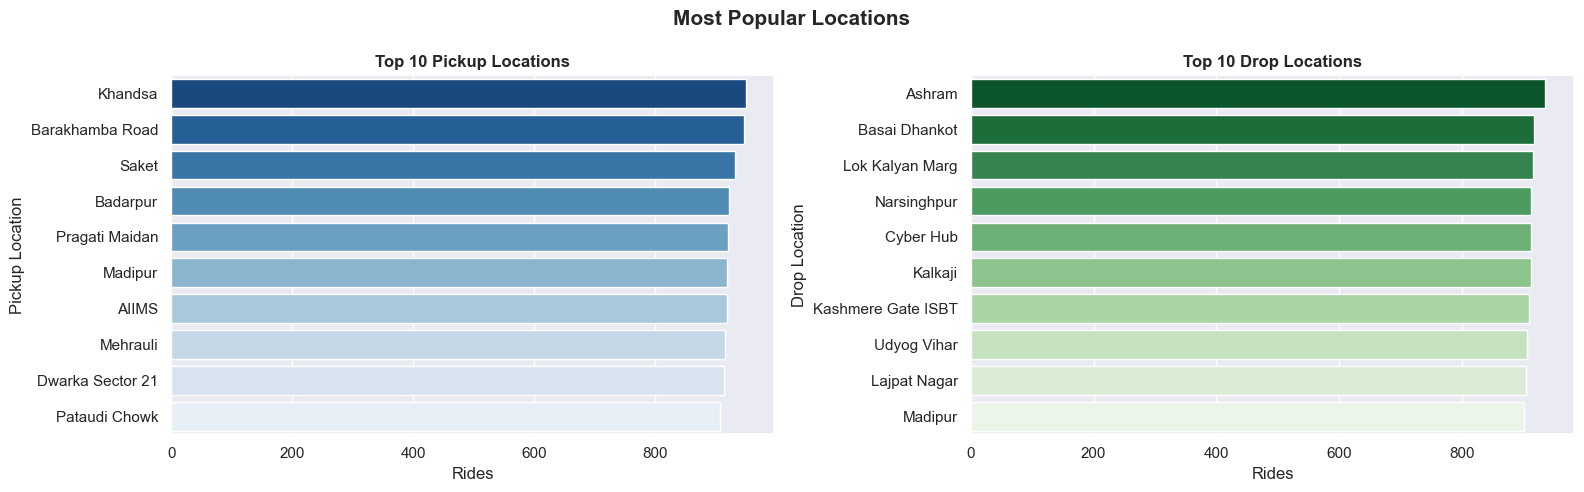

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 pickup locations
top_pickup = df['Pickup Location'].value_counts().head(10)
sns.barplot(y=top_pickup.index, x=top_pickup.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Pickup Locations', fontweight='bold')
axes[0].set_xlabel('Rides')

# Top 10 drop locations
top_drop = df['Drop Location'].value_counts().head(10)
sns.barplot(y=top_drop.index, x=top_drop.values, palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Drop Locations', fontweight='bold')
axes[1].set_xlabel('Rides')

plt.suptitle('Most Popular Locations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. 💰 Revenue & Distance Analysis

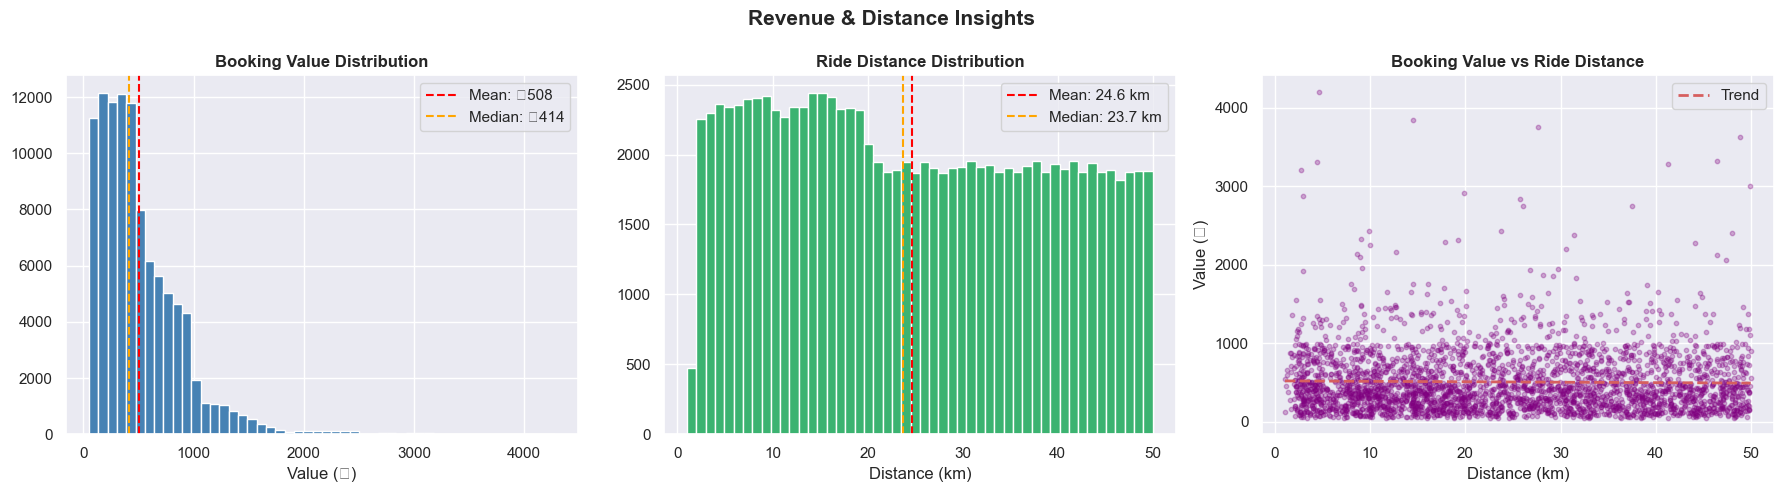

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Booking Value distribution
bv = df['Booking Value'].dropna()
axes[0].hist(bv, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Booking Value Distribution', fontweight='bold')
axes[0].set_xlabel('Value (₹)')
axes[0].axvline(bv.mean(), color='red', linestyle='--', label=f'Mean: ₹{bv.mean():.0f}')
axes[0].axvline(bv.median(), color='orange', linestyle='--', label=f'Median: ₹{bv.median():.0f}')
axes[0].legend()

# Ride Distance distribution
rd = df['Ride Distance'].dropna()
axes[1].hist(rd, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Ride Distance Distribution', fontweight='bold')
axes[1].set_xlabel('Distance (km)')
axes[1].axvline(rd.mean(), color='red', linestyle='--', label=f'Mean: {rd.mean():.1f} km')
axes[1].axvline(rd.median(), color='orange', linestyle='--', label=f'Median: {rd.median():.1f} km')
axes[1].legend()

# Booking Value vs Ride Distance scatter
sample = df[['Ride Distance','Booking Value']].dropna().sample(min(3000, len(df)), random_state=42)
axes[2].scatter(sample['Ride Distance'], sample['Booking Value'], alpha=0.3, color='purple', s=10)
z = np.polyfit(sample['Ride Distance'], sample['Booking Value'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Ride Distance'].min(), sample['Ride Distance'].max(), 100)
axes[2].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[2].set_title('Booking Value vs Ride Distance', fontweight='bold')
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('Value (₹)')
axes[2].legend()

plt.suptitle('Revenue & Distance Insights', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. ⭐ Ratings Analysis

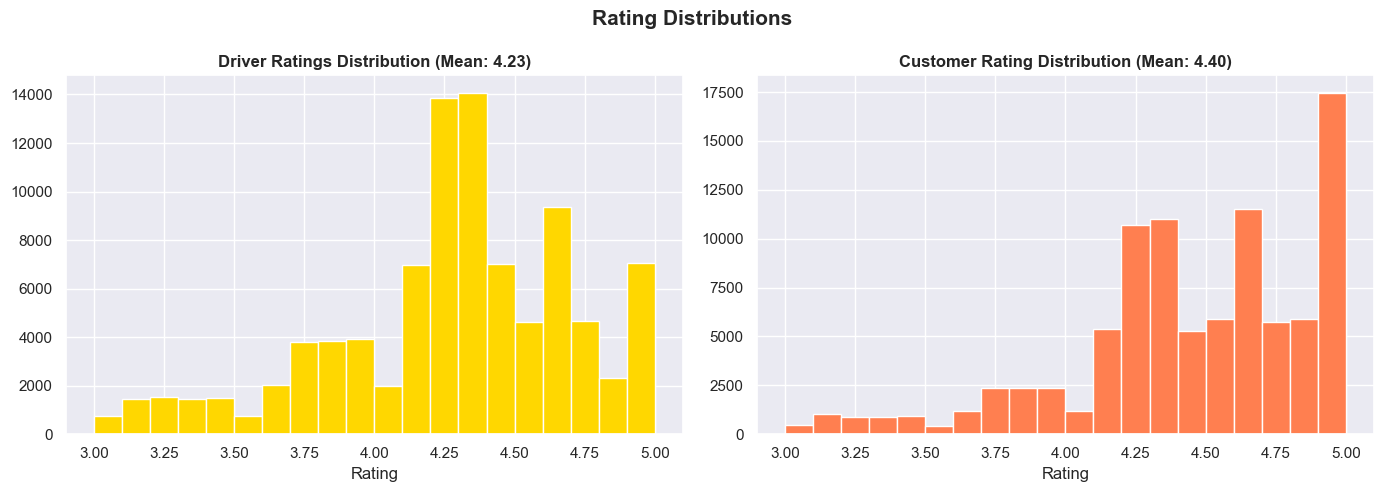

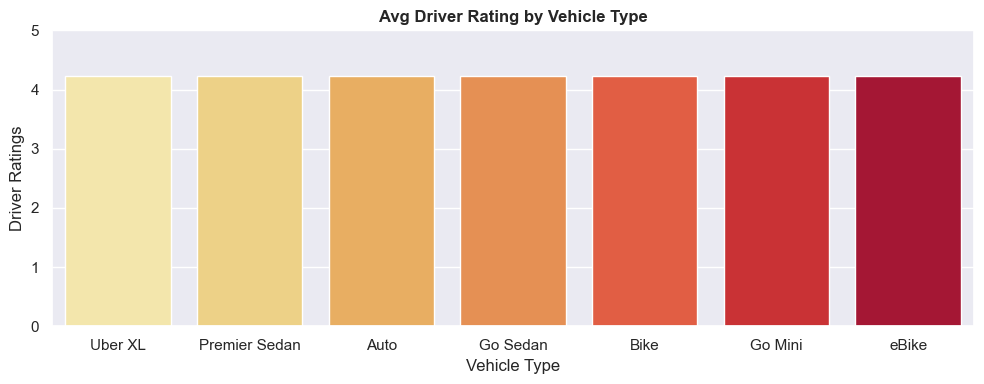

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Driver Ratings distribution
dr = df['Driver Ratings'].dropna()
axes[0].hist(dr, bins=20, color='gold', edgecolor='white')
axes[0].set_title(f'Driver Ratings Distribution (Mean: {dr.mean():.2f})', fontweight='bold')
axes[0].set_xlabel('Rating')

# Customer Rating distribution
cr = df['Customer Rating'].dropna()
axes[1].hist(cr, bins=20, color='coral', edgecolor='white')
axes[1].set_title(f'Customer Rating Distribution (Mean: {cr.mean():.2f})', fontweight='bold')
axes[1].set_xlabel('Rating')

plt.suptitle('Rating Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Avg Driver Rating by Vehicle Type
avg_rating = df.groupby('Vehicle Type')['Driver Ratings'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=avg_rating, x='Vehicle Type', y='Driver Ratings', palette='YlOrRd')
plt.title('Avg Driver Rating by Vehicle Type', fontweight='bold')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## 12. 💳 Payment Method Analysis

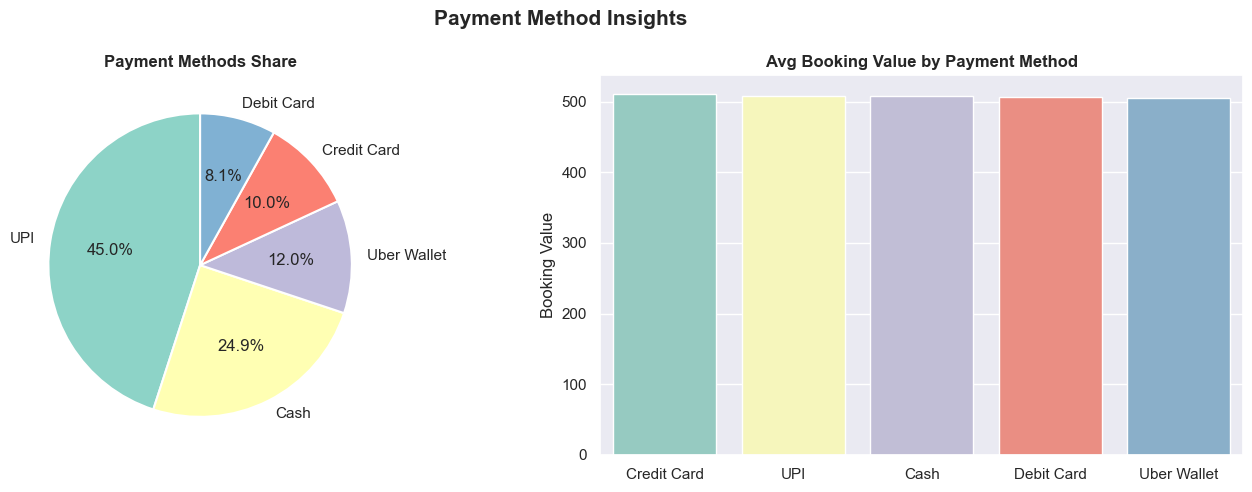

In [15]:
payment = df['Payment Method'].value_counts().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('Set3', len(payment))
axes[0].pie(payment.values, labels=payment.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Payment Methods Share', fontweight='bold')

# Avg booking value by payment method
pay_val = df.groupby('Payment Method')['Booking Value'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=pay_val, x='Payment Method', y='Booking Value', palette='Set3', ax=axes[1])
axes[1].set_title('Avg Booking Value by Payment Method', fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Payment Method Insights', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. 🔥 Correlation Heatmap

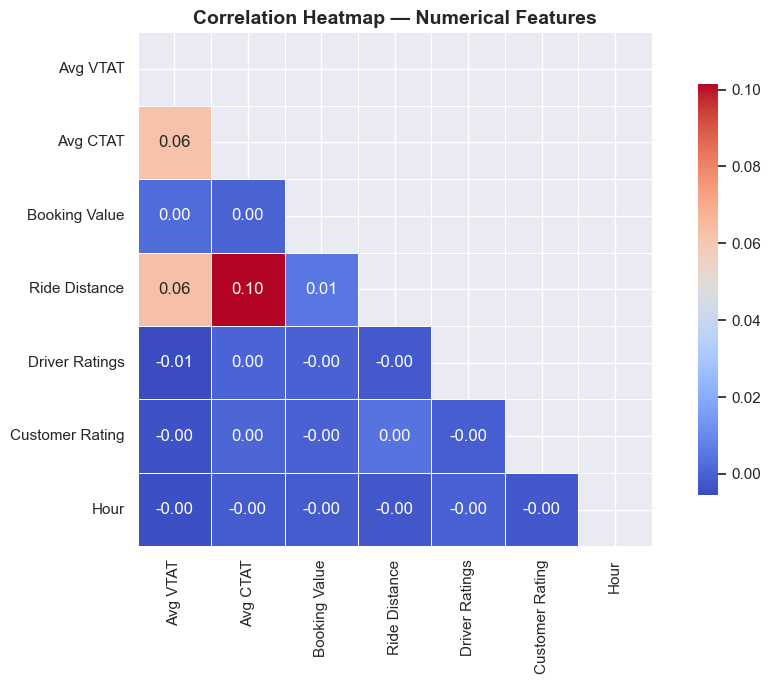

In [16]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Hour']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. ⏱️ Turnaround Time Analysis (VTAT & CTAT)

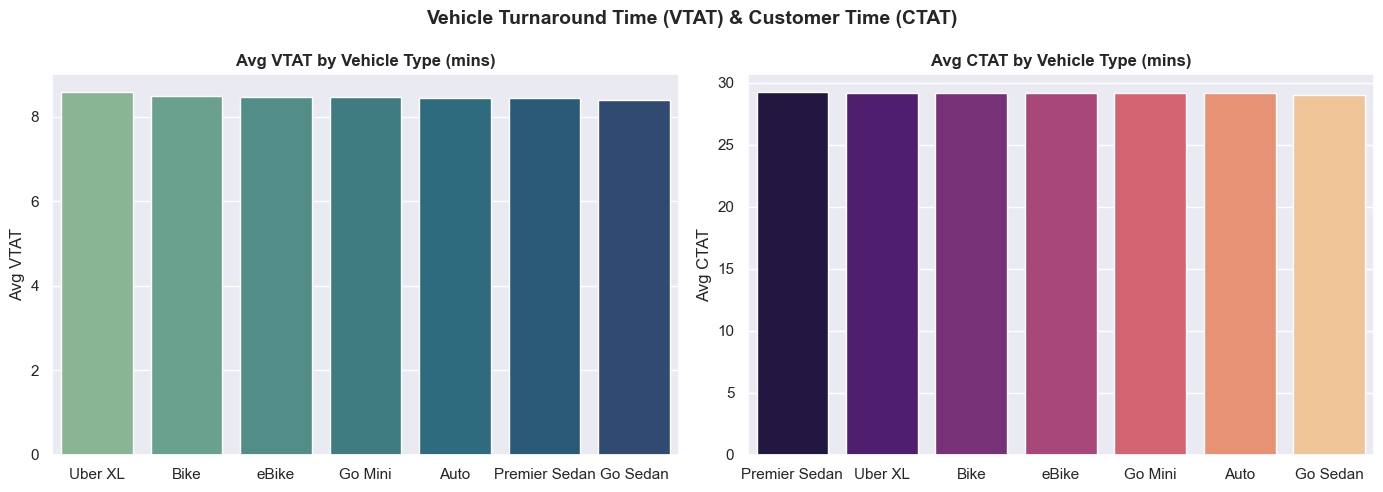

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VTAT by Vehicle Type
vtat = df.groupby('Vehicle Type')['Avg VTAT'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=vtat, x='Vehicle Type', y='Avg VTAT', palette='crest', ax=axes[0])
axes[0].set_title('Avg VTAT by Vehicle Type (mins)', fontweight='bold')
axes[0].set_xlabel('')

# CTAT by Vehicle Type
ctat = df.groupby('Vehicle Type')['Avg CTAT'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=ctat, x='Vehicle Type', y='Avg CTAT', palette='magma', ax=axes[1])
axes[1].set_title('Avg CTAT by Vehicle Type (mins)', fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Vehicle Turnaround Time (VTAT) & Customer Time (CTAT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. 📋 Key Summary Statistics

In [18]:
total_rides       = len(df)
success_rides     = df[df['Booking Status'] == 'Success'].shape[0]
total_revenue     = df['Booking Value'].sum()
avg_distance      = df['Ride Distance'].mean()
avg_driver_rating = df['Driver Ratings'].mean()
avg_cust_rating   = df['Customer Rating'].mean()
cancel_pct        = (df['Is_Cancelled'].sum() / total_rides) * 100

summary = pd.DataFrame({
    'Metric': [
        'Total Bookings', 'Successful Rides', 'Cancellation Rate',
        'Total Revenue (₹)', 'Avg Ride Distance (km)',
        'Avg Driver Rating', 'Avg Customer Rating'
    ],
    'Value': [
        f'{total_rides:,}',
        f'{success_rides:,}',
        f'{cancel_pct:.1f}%',
        f'₹{total_revenue:,.0f}',
        f'{avg_distance:.2f} km',
        f'{avg_driver_rating:.2f} / 5',
        f'{avg_cust_rating:.2f} / 5'
    ]
})

summary.style.set_properties(**{'font-size': '14pt', 'text-align': 'left'})\
             .hide(axis='index')

Metric,Value
Total Bookings,"150,000"
Successful Rides,0
Cancellation Rate,25.0%
Total Revenue (₹),"₹51,846,183"
Avg Ride Distance (km),24.64 km
Avg Driver Rating,4.23 / 5
Avg Customer Rating,4.40 / 5


---
## ✅ EDA Complete!

**Key areas explored:**
1. Dataset shape, dtypes, and missing values
2. Booking status distribution
3. Vehicle type patterns and revenue
4. Hourly, daily, and monthly booking trends
5. Cancellation reasons (customer & driver)
6. Top pickup and drop locations
7. Revenue and ride distance distributions
8. Driver and customer ratings
9. Payment method preferences
10. Correlation between numeric features
11. Turnaround time (VTAT & CTAT) by vehicle type